# H3 Test

---

A Jupyter notebook to test automating the downloading and display of H3 hexagon population data.

Learning resources I've used:

* https://realpython.com/python-download-file-from-url/

### Downloading the files

In [3]:
from urllib.request import urlretrieve # built in, handles simple requests
import requests # handles more complicated web request/ larger files/ multiple downloads

import pycountry

In [ ]:
# Example URL for ANDORRA
# https://geodata-eu-central-1-kontur-public.s3.amazonaws.com/kontur_datasets/kontur_population_AD_20231101.gpkg.gz

# Therefore base URL is
base_url = (
    "https://geodata-eu-central-1-kontur-public.s3.amazonaws.com/kontur_datasets/"
    "kontur_population_{country_alpha_2}_20231101.gpkg.gz"
    )

selected_country = "Italy" # example selected country

selected_country_alpha_2 = pycountry.countries.get(name=selected_country).alpha_2
print(selected_country_alpha_2)

target_url = base_url.format(country_alpha_2=selected_country_alpha_2)
print(target_url)

IT
https://geodata-eu-central-1-kontur-public.s3.amazonaws.com/kontur_datasets/kontur_population_IT_20231101.gpkg.gz


In [ ]:
response = requests.get(target_url) # simple way of downloading

200

In [13]:
# Can do the same with data streaming
response = requests.get(target_url, stream=True)

In [14]:
response.headers

{'x-amz-id-2': 'TnhSeY9EIm+0AULOXLLMGYkcVRAZUM9OHu8gJ9H/FDQ/OXk7Y0r8k03MfSBWlQlhzDO7aDyBxxPo+ZUVLdN6gg==', 'x-amz-request-id': 'C8N2WFEQSAVNK1R6', 'Date': 'Wed, 17 Sep 2025 12:43:07 GMT', 'Last-Modified': 'Tue, 31 Oct 2023 16:31:54 GMT', 'ETag': '"e2af61567c6f486471f347294dd6d779-3"', 'x-amz-server-side-encryption': 'AES256', 'Accept-Ranges': 'bytes', 'Content-Type': 'application/geopackage+sqlite3', 'Content-Length': '21057834', 'Server': 'AmazonS3'}

In [ ]:
# 
with requests.get(target_url, stream=True) as response:
    with open(f"{selected_country_alpha_2}_H3_population_density_map.gpkg.gz", mode="wb") as file:
        for chunk in response.iter_content(chunk_size= 10 * 1024):
            file.write(chunk)

This (above) downloads the population density but we need to unzip etc. so lets make a function

In [32]:
from pycountry import countries
import os
from pathlib import Path

In [33]:
def download_H3_population_density_zipped(country_name, output_dir="H3_zipped_pop_density_maps", progress_callback= None, overwrite_download = False):
    try:
        selected_country = countries.get(name = country_name)
        selected_country_alpha_2 = selected_country.alpha_2
    except LookupError:
        return False, f"Country, {country_name}, not found"
    
    base_url = (
    "https://geodata-eu-central-1-kontur-public.s3.amazonaws.com/kontur_datasets/"
    "kontur_population_{country_alpha_2}_20231101.gpkg.gz"
    )

    target_url = base_url.format(country_alpha_2=selected_country_alpha_2)

    output_file = Path(output_dir)/ f"{selected_country_alpha_2}_H3_population_density_map.gpkg.gz"


    # Check if file exists and we shouldn't overwrite
    if not overwrite_download and os.path.exists(output_file):
        return True, f"File already exists at:\n{output_file}"

    try:
        # Use session to enable connection pooling and compression
        with requests.session() as session:

            with session.get(target_url, stream=True) as response:
                response.raise_for_status()
                total_size = int(response.headers.get("Content-Length",0))

                with open(output_file, mode="wb") as file:
                    
                    downloaded = 0
                    for chunk in response.iter_content(chunk_size= 10 * 1024):
                        file.write(chunk)
                        downloaded += len(chunk)
                        if progress_callback and total_size>0:
                            progress = int(100* downloaded/total_size)
                            progress_callback(progress)
    
    except requests.exceptions.RequestException as e:
        # Handle incomplete shit
        if Path.exists(output_file):
            Path.unlink(output_file)
        return False, f"Download failed, {str(e)}"
    except Exception as e:
        return False, f"Error occured: {str(e)}"
    
# Test run
download_H3_population_density_zipped("Italy")


Now need to decompress (used chatgpt as couldnt see a better way to uncompress)


In [37]:
import gzip, shutil
import geopandas as gpd

output_dir = "H3_zipped_pop_density_maps"

gz_path = Path(output_dir)/ f"{selected_country_alpha_2}_H3_population_density_map.gpkg.gz"

gpkg_path = gz_path.with_suffix("")

# Unzip

with gzip.open(gz_path, 'rb') as f_in, open(gpkg_path, "wb") as f_out:
    shutil.copyfileobj(f_in, f_out)

gdf = gpd.read_file(gpkg_path)
gdf.head()

,h3,population,geometry
0,883f36416bfffff,10.0,"POLYGON ((1430206.608 4282104.088, 1430009.21 ..."
1,883f364155fffff,9.0,"POLYGON ((1433124.265 4283497.547, 1432926.673..."
2,883f364147fffff,35.0,"POLYGON ((1431084.032 4282960.942, 1430886.569..."
3,883f364143fffff,16.0,"POLYGON ((1431961.6 4283817.799, 1431764.072 4..."
4,883f36410dfffff,279.0,"POLYGON ((1431369.082 4281784.028, 1431171.62 ..."


Now need to work out how to plot the H3 hexagons. Have found this online which works on the same Kontur population data sets (https://www.kaggle.com/code/mpwolke/population-density-h3-hexagons-gpkg) 

In [38]:
import matplotlib as plt

gdf.shape


(312901, 3)

In [40]:
gdf.population.value_counts()

population
1.0       43006
2.0       18619
3.0       14762
4.0       12130
5.0       10511
          ...  
5904.0        1
5451.0        1
2827.0        1
5546.0        1
5665.0        1
Name: count, Length: 5600, dtype: int64

In [41]:
plt.rcParams['figure.figsize']= 10,10
plt.rcParams['legend.loc']='best'

In [42]:
print(gdf.geometry[4])

POLYGON ((1431369.0820869391 4281784.028202965, 1431171.619659962 4281106.162845592, 1431654.085035121 4280607.175584242, 1432334.0280784785 4280785.988974948, 1432531.554528163 4281463.835014849, 1432049.0739159167 4281962.886987321, 1431369.0820869391 4281784.028202965))


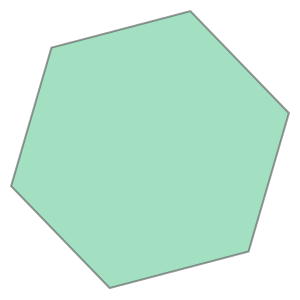

In [46]:
gdf.geometry[4]

<Axes: >

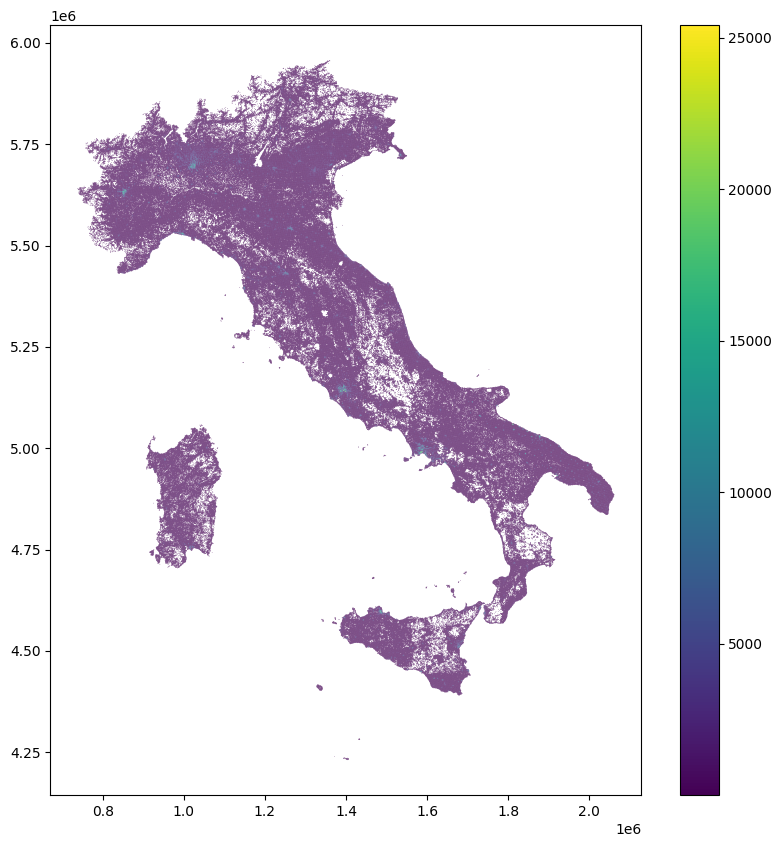

In [52]:
gdf.plot(
    column="population",
    legend=True,
)


In [ ]:
import folium
# gdf.explore()

# this is commented out because its bloody hard to run

https://www.youtube.com/watch?v=I9mt37nd2kg